**Здесь должна быть указана группа, фамилия, имя студента**

# Практическая работа 2. Работа с данными в конвейере машинного обучения

Набор данных представляет собой данные об автомобилях, представленных на вторичном рынке.  
Содержит следующие параметры:  
**Make** - компания-производитель  
**Model** - модель автомобиля  
**Year** - год выпуска  
**Style** - тип кузова  
**Distance** - пробег  
**Engine_capacity(cm3)** - объем двигателя  
**Fuel_type** - тип топлива  
**Transmission** - передача  
**Price(euro)** - цена  

**Задача**  
Выполнить очистку датасета, кодирование данных и разведочный анализ данных с учетом дальнейшего использования полученного результата (датасета) в обучении модели.

## 1. Выполнить импорт библиотек  
Для работы вам понадобятся библиотеки Numpy, Pandas, MatPlotLib и Seaborn.  
При желании вы можете использовать и другие библиотеки; в этом случае в описании работы нужно давать краткое описание используемых функций.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # библиотека для визуализации данных
import seaborn as sns # еще одна библиотека для продвинутой визуализации данных

from sklearn.preprocessing import StandardScaler # библиотека для стандартизации данных
from sklearn.preprocessing import LabelEncoder # библиотека для кодирования категориальных переменных

## 2. Считать файл в DataFrame  

In [2]:
data = pd.read_csv("cars.csv")

**Вывести информацию о датафрейме**

In [3]:
data.head()

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,Toyota,Prius,2011,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0
1,Renault,Grand Scenic,2014,Universal,135000.0,1500.0,Diesel,Manual,8550.0
2,Volkswagen,Golf,1998,Hatchback,1.0,1400.0,Petrol,Manual,2200.0
3,Renault,Laguna,2012,Universal,110000.0,1500.0,Diesel,Manual,6550.0
4,Opel,Astra,2006,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0


**Проверить датафрейм на наличие дубликатов - повторяющихся строк.**  
Вывести количество дубликатов в датафрейме. 
Удалить дубликаты, вывести информацию о скорректированном датафрейме.  
***Подсказка:*** *можно использовать методы `.drop_duplicates()` и `.reset_index()`*

In [4]:
print(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
data.info()

3743
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37264 entries, 0 to 37263
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  37151 non-null  object 
 1   Model                 37261 non-null  object 
 2   Year                  37264 non-null  int64  
 3   Style                 37231 non-null  object 
 4   Distance              37264 non-null  float64
 5   Engine_capacity(cm3)  37264 non-null  float64
 6   Fuel_type             37264 non-null  object 
 7   Transmission          37264 non-null  object 
 8   Price(euro)           37264 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 2.6+ MB


## 3. Определить тип данных для признаков датасета  
В этом поле указать типы данных, встречающиеся в датасете.  

object, int64, float64


Если есть нечисловые (категориальные) признаки, перечислить, какие именно.  
***Подсказка:*** *При желании этот пункт можно выполнить автоматически, добавив в ячейку ниже код на Python*

In [5]:
data_types = data.dtypes
print(data_types)

Make                     object
Model                    object
Year                      int64
Style                    object
Distance                float64
Engine_capacity(cm3)    float64
Fuel_type                object
Transmission             object
Price(euro)             float64
dtype: object


## 4. Выполнить кодирование категориальных признаков (привести их к числовым)
## Рекомендуемая последовательность действий:
### 4.1. Определите значения, которые принимают категориальные признаки, и сколько раз они встречаются в датасете  
Выведите полученные значения.  
***Подсказка:*** *используйте метод `.value_counts()`*

In [6]:
categorical_columns = data.select_dtypes(include=['object']).columns

for column in categorical_columns:
	print(f"Value counts for {column}:")
	print(data[column].value_counts())
	print("\n")

Value counts for Make:
Make
Volkswagen      3953
Mercedes        3501
Toyota          3427
BMW             2998
Renault         2685
                ... 
Lamborghini        1
McLaren            1
Saturn             1
Aston Martin       1
Xpeng              1
Name: count, Length: 85, dtype: int64


Value counts for Model:
Model
E Class     1251
5 Series    1212
Passat      1025
Astra        945
Megane       914
            ... 
Cherry         1
Applouse       1
BT-50          1
MX-6           1
620            1
Name: count, Length: 828, dtype: int64


Value counts for Style:
Style
Sedan        11437
Universal     6713
Hatchback     6091
Crossover     4383
SUV           3578
Minivan       3111
Coupe          704
Microvan       488
Combi          397
Pickup         172
Cabriolet      157
Name: count, dtype: int64


Value counts for Fuel_type:
Fuel_type
Diesel            17198
Petrol            13175
Metan/Propan       4169
Hybrid             1976
Plug-in Hybrid      464
Electric          

### 4.2. Определите число уникальных значений в каждом категориальном признаке  
Выведите полученный результат  
***Подсказка:*** *используйте метод `.nunique()`*

In [7]:
for column in categorical_columns:
	print(column, data[column].nunique()) 

Make 85
Model 828
Style 11
Fuel_type 6
Transmission 2


### 4.3. Проанализируйте полученные значения и возможности сокращения количества категорий
Если категориальные признаки представлены большим количеством категорий (более 25), имеет смысл попытаться их сократить.  
Возможные методы: 
1. Агрегация (объединение) категорий.
2. Объединение редко встречающихся категорий в одну.  
Если значения категории встречаются редко, обычно их можно заменить без значительной потери точности на искусственно введенную категорию "rare" (редкие).

Обоснуйте критерий, по которому вы предполагаете определять редкие значения.


***тут должен быть ваш текст***   
@@@@@@@@@@@

Если в категориальных признаках меньше 25 уникальных значений, сокращать их обычно не требуется.
В вашем случае:

Style — 11 уникальных значений
Fuel_type — 6 уникальных значений
Transmission — 2 уникальных значения
Это немного, поэтому сокращать категории не нужно.
Оставьте их как есть, если среди них нет очень редких значений (например, встречающихся 1-2 раза). Если такие есть, их можно объединить в категорию "rare", но это не обязательно при таком количестве уникальных значений.

@@@@@@@@@@@@@@@@

Выполните редактирование датафрейма, если необходимо.  
**ВАЖНО! Перед манипуляциями с датасетом, которые приводят к сокращению содержащихся данных, рекомендуется создать его копию!**

In [8]:
dataset = data.copy()

top_n = 28  # top28
top_makes = dataset["Make"].value_counts().nlargest(top_n).index
dataset["Make"] = dataset["Make"].apply(lambda x: x if x in top_makes else "Other")

top_n = 60  # например, топ-40 моделей
top_models = dataset["Model"].value_counts().nlargest(top_n).index
dataset["Model"] = dataset["Model"].apply(lambda x: x if x in top_models else "Other")


categorical_columns = dataset.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    print(f"Value counts for {column}:")
    print(dataset[column].value_counts())
    print("\n")

Value counts for Make:
Make
Volkswagen    3953
Mercedes      3501
Toyota        3427
BMW           2998
Renault       2685
Opel          2220
Skoda         1892
Audi          1786
Ford          1527
Dacia         1524
Nissan        1464
Other         1400
Hyundai       1341
Honda         1029
KIA            750
Mitsubishi     729
Vaz            654
Lexus          651
Volvo          636
Mazda          539
Peugeot        469
Chevrolet      365
Citroen        337
Land Rover     313
Seat           286
Fiat           237
Porsche        204
Suzuki         176
Subaru         171
Name: count, dtype: int64


Value counts for Model:
Model
Other            14463
E Class           1251
5 Series          1212
Passat            1025
Astra              945
                 ...  
Cayenne            153
Sportage           152
Series (W124)      151
XC60               150
Sandero            140
Name: count, Length: 61, dtype: int64


Value counts for Style:
Style
Sedan        11437
Universal     6713
Ha

### 4.4. Выполните кодирование категориальных признаков 
***ВАЖНО! Перед манипуляциями с датасетом, которые приводят к изменению содержащихся данных, рекомендуется создать его копию!***  

#### Кодирование бинарных признаков (если они есть в датасете):

In [9]:
# здесь должен быть ваш код!
dataset.loc[dataset["Transmission"] == "Automatic", "Transmission"] = 1
dataset.loc[dataset["Transmission"] == "Manual", "Transmission"] = 0


dataset.head()

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,Toyota,Prius,2011,Hatchback,195000.0,1800.0,Hybrid,1,7750.0
1,Renault,Grand Scenic,2014,Universal,135000.0,1500.0,Diesel,0,8550.0
2,Volkswagen,Golf,1998,Hatchback,1.0,1400.0,Petrol,0,2200.0
3,Renault,Other,2012,Universal,110000.0,1500.0,Diesel,0,6550.0
4,Opel,Astra,2006,Universal,200000.0,1600.0,Metan/Propan,0,4100.0


#### Кодирование многозначных категориальных признаков:  

**Выполнить One-hot кодирование многозначных (небинарных) категориальных признаков**  
Если вы выбираете способ кодирования One-hot, в библиотеке Pandas он может удобно выполняться с использованием метода `.get_dummies()`.  
Метод применяется к исходному датафрейму, ориентируется на тип данных. Внимание! С числовыми признаками он не работает!  
**Рекомендация:** создайте отдельный датафрейм с кодированием категориальных признаков способом One-hot

In [10]:
# Получаем список категориальных признаков (кроме бинарного 'Transmission', который уже закодирован)
multi_cat_columns = ["Make", "Model", "Style", "Fuel_type"]

#One-hot
df_ohe = pd.get_dummies(dataset, columns=multi_cat_columns, drop_first=True)

df_ohe.head()

,Year,Distance,Engine_capacity(cm3),Transmission,Price(euro),Make_BMW,Make_Chevrolet,Make_Citroen,Make_Dacia,Make_Fiat,...,Style_Minivan,Style_Pickup,Style_SUV,Style_Sedan,Style_Universal,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid
0,2011,195000.0,1800.0,1,7750.0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2014,135000.0,1500.0,0,8550.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1998,1.0,1400.0,0,2200.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2012,110000.0,1500.0,0,6550.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,2006,200000.0,1600.0,0,4100.0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False


**Выполнить Label encoding кодирование многозначных (небинарных) категориальных признаков**

In [ ]:
df_se = dataset.copy()
multi_cat_columns = ["Make", "Model", "Style", "Fuel_type"]

# Применяем LabelEncoder к каждому признаку
le = LabelEncoder()
for col in multi_cat_columns:
    df_se[col] = le.fit_transform(df_se[col])

df_se.head()

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,25,38,2011,4,195000.0,1800.0,2,1,7750.0
1,20,24,2014,10,135000.0,1500.0,0,0,8550.0
2,27,23,1998,4,1.0,1400.0,4,0,2200.0
3,20,34,2012,10,110000.0,1500.0,0,0,6550.0
4,16,7,2006,10,200000.0,1600.0,3,0,4100.0


**Вывести информацию о датафрейме и первые 5 строк датафрейма**

In [ ]:
# ???? здесь должен быть ваш код?
df_se.isna().sum()
df_ohe.isna().sum()

Year                        0
Distance                    0
Engine_capacity(cm3)        0
Transmission                0
Price(euro)                 0
                           ..
Fuel_type_Electric          0
Fuel_type_Hybrid            0
Fuel_type_Metan/Propan      0
Fuel_type_Petrol            0
Fuel_type_Plug-in Hybrid    0
Length: 108, dtype: int64

## 5. Разведочный анализ данных и улучшение датасета

### 5.1. Выявление неполных данных и работа с ними
**Проверить датасет на наличие неопределенных значений, вывести результаты проверки.**

In [ ]:
print("Общее количество записей:", len(dataset))
print(dataset[dataset["Style"].isna()])

Общее количество записей: 37264
             Make    Model  Year Style   Distance  Engine_capacity(cm3)  \
465    Mitsubishi    Other  2004   NaN   300000.0                2500.0   
1121         Ford   Fusion  2014   NaN   126000.0                2000.0   
1139   Volkswagen   Passat  2016   NaN   116000.0                1800.0   
2685   Volkswagen    Other  2012   NaN   200100.0                3000.0   
3135       Subaru    Other  2008   NaN        0.0                2000.0   
5418   Volkswagen     Golf  2000   NaN    23000.0                1900.0   
5535         Opel   Zafira  2004   NaN   480000.0                1800.0   
5618        Other    Other  1949   NaN    11111.0                2000.0   
6541    Chevrolet    Other  2012   NaN        0.0                1800.0   
7918       Subaru    Other  2013   NaN   148000.0                2000.0   
9051      Porsche    Other  2014   NaN    70000.0                3800.0   
10036     Renault   Kadjar  2019   NaN    35000.0                150

**Если в датасете есть неопределенные значения, принять обоснованное решение об исправлении ситуации**  
Дефектные примеры можно исключить из выборки или заполнить отсутствующие значения.  
Обоснование выбранного решения привести этой ячейке ниже.  

***тут должен быть ваш текст***   

Выполнить действия по очистке датасета от неопределенных значений.

In [ ]:
# здесь должен быть ваш код!
dataset = dataset.dropna(subset=["Style"]).reset_index(drop=True)
print("Общее количество записей:", len(dataset))
print(dataset[dataset["Style"].isna()])

Общее количество записей: 37231
Empty DataFrame
Columns: [Make, Model, Year, Style, Distance, Engine_capacity(cm3), Fuel_type, Transmission, Price(euro)]
Index: []


### 5.2. Статистический анализ, выявление выбросов, некорректных значений и работа с ними
**Определить "стандартные" статистические параметры для числовых данных датасета.**  
***Подсказка:*** *используйте метод `.describe()`*

In [98]:
print(dataset.describe())

               Year      Distance  Engine_capacity(cm3)   Price(euro)
count  37231.000000  3.723100e+04          37231.000000  3.723100e+04
mean    2007.709167  4.759487e+05           1858.963015  9.568689e+03
std        8.290639  4.593386e+06            707.464458  5.285487e+04
min     1900.000000  0.000000e+00              0.000000  1.000000e+00
25%     2004.000000  9.000000e+04           1499.000000  3.300000e+03
50%     2009.000000  1.700000e+05           1800.000000  6.490000e+03
75%     2014.000000  2.300000e+05           2000.000000  1.179900e+04
max     2021.000000  1.000000e+08           9999.000000  1.000000e+07


**Вывести гистограммы (распределение) значений по признакам 'Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)'**

Аномалии Distance:
 Empty DataFrame
Columns: [Make, Model, Year, Style, Distance, Engine_capacity(cm3), Fuel_type, Transmission, Price(euro)]
Index: []
Аномалии Price(euro):
 Empty DataFrame
Columns: [Make, Model, Year, Style, Distance, Engine_capacity(cm3), Fuel_type, Transmission, Price(euro)]
Index: []


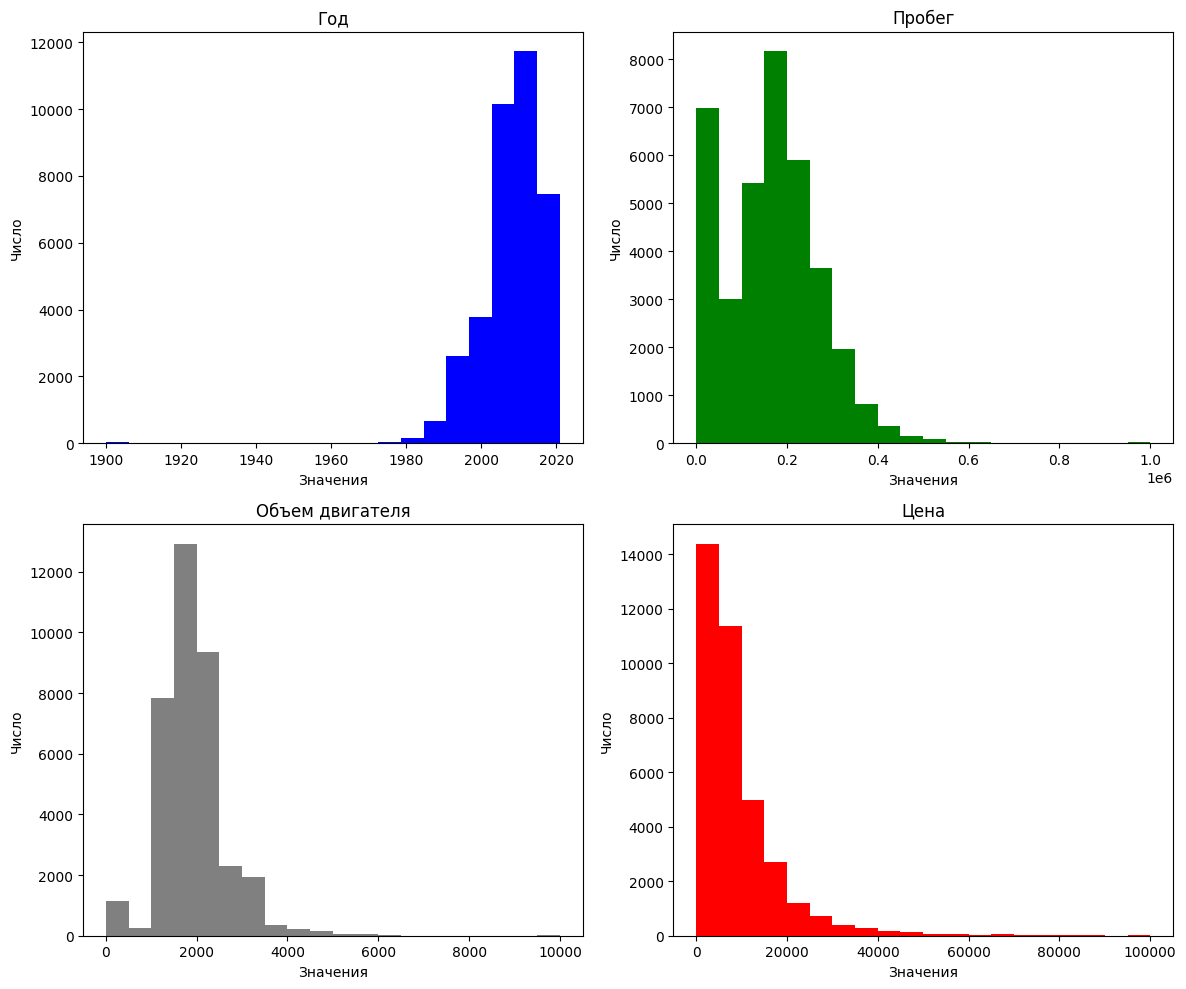

In [38]:
# здесь должен быть ваш код!
# print(dataset["Distance"].max())
anomalies1 = dataset[(dataset["Distance"] > 1000000) | (dataset["Distance"] < 0)]
anomalies2 = dataset[(dataset["Price(euro)"] > 200000) | (dataset["Price(euro)"] < 0)]

print("Аномалии Distance:\n", anomalies1)
print("Аномалии Price(euro):\n", anomalies2)

# Вывести гистограммы для признаков 'Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)'
filtered_dataset_distance = dataset[(dataset["Distance"] >= 0) & (dataset["Distance"] <= 1000000)]
filtered_dataset_price = dataset[(dataset["Price(euro)"] >= 0) & (dataset["Price(euro)"] <= 100000)]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(dataset["Year"], bins=20, color="blue")
plt.title("Год")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.subplot(2, 2, 2)
plt.hist(filtered_dataset_distance["Distance"], bins=20, color="green")
plt.title("Пробег")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.subplot(2, 2, 3)
plt.hist(dataset["Engine_capacity(cm3)"], bins=20, color="grey")
plt.title("Объем двигателя")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.subplot(2, 2, 4)
plt.hist(filtered_dataset_price["Price(euro)"], bins=20, color="red")
plt.title("Цена")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.tight_layout()
plt.show()

### 5.3. Выявление выбросов и аномальных значений признаков и работа с ними  
**ПОДСКАЗКА:** Датасет имеет явные аномалии, особенно в признаках `Distance` и `Price(euro)`. 
Чтобы лучше понять эти аномалии, ВНИМАТЕЛЬНО изучите результаты статистического анализа выше.  
Возможно, полезную информацию вы сможете получить из графиков в логарифмическом масштабе.
Можно выявить выбросы на диаграмме "ящик с усами" (box plot), с помощью статистических метрик (см. презентацию к лекции и пример к практической работе).  
Также, так как задача хорошо интерпретируема мы можем почистить столбцы пользуясь здравым смыслом.  

In [ ]:
# здесь должен быть ваш код!

Анализ диаграмм, стат. параметров и обоснование выбранных решений по улучшению датасета привести в этой ячейке 

***тут должен быть ваш текст***   

Выполнить улучшение датасета

In [119]:
normal_data = dataset[
    ~(
        (dataset["Distance"] > 550000)
        | (dataset["Distance"] < 0)
        | (dataset["Price(euro)"] > 60000)
        | (dataset["Price(euro)"] < 1000)
        | (dataset["Year"] < 1980)
        | (dataset["Engine_capacity(cm3)"] > 5000)
        | (dataset["Engine_capacity(cm3)"] < 400)
    )
]

cleandataset = normal_data

**Вывести информацию о датасете после очистки**

In [117]:
print(cleandataset.describe())
# print(
#     "Строк с Engine_capacity:", len(dataset[dataset["Engine_capacity(cm3)"] < 200])
# )

               Year       Distance  Engine_capacity(cm3)   Price(euro)
count  33918.000000   33918.000000          33918.000000  33918.000000
mean    2008.480895  163848.056519           1897.555457   9191.965682
std        6.847289  100858.475526            575.840740   8303.808286
min     1980.000000       0.000000            400.000000   1000.000000
25%     2005.000000   97000.000000           1500.000000   3650.000000
50%     2009.000000  170000.000000           1800.000000   6700.000000
75%     2014.000000  226751.750000           2000.000000  11999.000000
max     2021.000000  550000.000000           5000.000000  60000.000000


**Вывести гистограммы (распределение) значений по признакам 'Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)' для очищенного датасета**

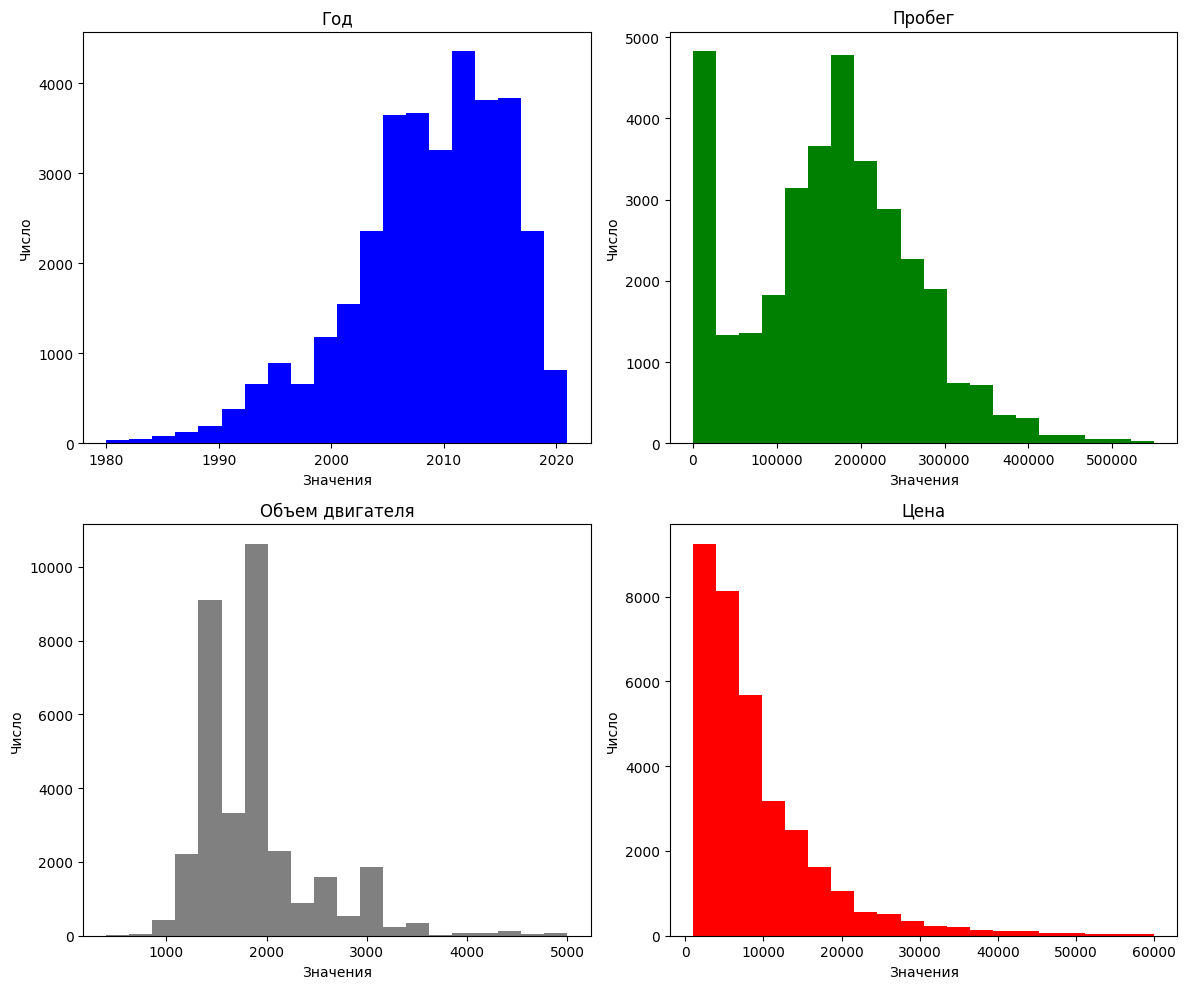

In [118]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(cleandataset["Year"], bins=20, color="blue")
plt.title("Год")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.subplot(2, 2, 2)
plt.hist(cleandataset["Distance"], bins=20, color="green")
plt.title("Пробег")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.subplot(2, 2, 3)
plt.hist(cleandataset["Engine_capacity(cm3)"], bins=20, color="grey")
plt.title("Объем двигателя")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.subplot(2, 2, 4)
plt.hist(cleandataset["Price(euro)"], bins=20, color="red")
plt.title("Цена")
plt.xlabel("Значения")
plt.ylabel("Число")

plt.tight_layout()
plt.show()

### 5.4 Корреляционный анализ
Посчитать матрицу взаимной корреляци параметров и вывести ее в виде тепловой карты.  
***Подсказка:*** *для вычисления матрицы взаимной корреляции используйте метод `.corr()`*  
*для вывода тепловой карты используйте функцию `sns.heatmap`*

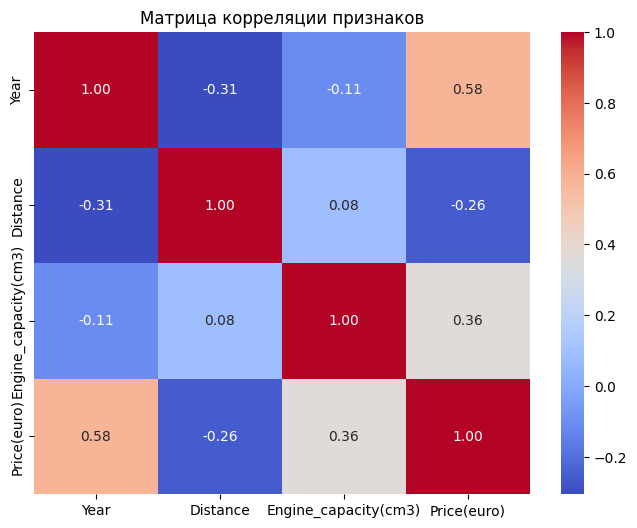

In [ ]:
# Корреляционный анализ и тепловая карта
corr_matrix = cleandataset.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляции признаков")
plt.show()

**Проанализировать матрицу взаимной корреляции параметров, выделить наиболее взаимнозависимые. Описать ваши выводы текстом в этой ячкйке ниже.**  

ТЕКСТ
текст

### Дополнительная информация:  
Для анализа взаимных зависимостей признаков есть сильный инструмент:  
pairplot seaborn 
`.pairplot(data, hue, palette)`

Он формирует группу диаграмм, где по диагонали - гистограммы распределения отдельных признаков, а другие элементы - попарные скатерограммы.
Но интерпретация полученной информации требует опыта. Если признаков много (больше 5-10) то будет отрисовывать ОЧЕНЬ! долго.
Ниже приведен пример кода с использованием pairplot. Для его запуска укажите тип ячейки code.  
***Использование этого инструмента не обязательно*** 

## 6. Масштабирование признаков

Проанализируйте интервалы значений и распределение признаков и при необходимости выполните нормализацию, стандартизацию или нелинейное преобразование (например, логарифмическое).  
Выбор действия обоснуйте  

***тут должен быть ваш текст***   

Выведите диаграмму рассеяния до и после нормализации

In [132]:
# Шаг 1: Нормализация "Года"
year_min = cleandataset["Year"].min()  # 1980
year_max = cleandataset["Year"].max()  # 2021
cleandataset.loc[:, "Year_norm"] = (cleandataset["Year"] - year_min) / (
    year_max - year_min
)

# Шаг 2: Логарифмическое преобразование
cleandataset.loc["Distance_log"] = np.log1p(cleandataset["Distance"])
cleandataset.loc["Engine_capacity_log"] = np.log1p(cleandataset["Engine_capacity(cm3)"])
cleandataset.loc["Price_log"] = np.log1p(cleandataset["Price(euro)"])

# Шаг 3: Стандартизация
scaler = StandardScaler()

# Применяем стандартизацию к каждому признаку отдельно
cleandataset.loc[:,"Distance_std"] = scaler.fit_transform(cleandataset[["Distance_log"]])
cleandataset.loc[:,"Engine_capacity_std"] = scaler.fit_transform(
    cleandataset[["Engine_capacity_log"]]
)
cleandataset.loc[:,"Price_std"] = scaler.fit_transform(cleandataset[["Price_log"]])

# Проверяем результат
print(
    cleandataset[
        ["Year_norm", "Distance_std", "Engine_capacity_std", "Price_std"]
    ].describe()
)

          Year_norm  Distance_std  Engine_capacity_std     Price_std
count  33918.000000  3.391800e+04         3.391800e+04  3.391800e+04
mean       0.694656 -1.956622e-16         1.233677e-15 -2.322807e-15
std        0.167007  1.000015e+00         1.000015e+00  1.000015e+00
min        0.000000 -3.917477e+00        -5.494419e+00 -2.270584e+00
25%        0.609756  1.507007e-01        -7.076000e-01 -7.096836e-01
50%        0.707317  3.494893e-01        -4.679850e-02  2.282375e-02
75%        0.829268  4.515459e-01         3.350988e-01  7.256502e-01
max        1.000000  7.654720e-01         3.657015e+00  2.667069e+00


## 7. Конструирование признака  
**Добавить в датафрейм столбец (признак): пробег автомобиля в год.**  
Годом начала эксплуатации автомобиля принять год его выпуска, год завершения эксплуатации - 2024.

In [135]:
# Исправленный код с использованием .loc
cleandataset.loc[:, "Years_in_use"] = 2024 - cleandataset["Year"]
cleandataset.loc[:, "Years_in_use"] = cleandataset["Years_in_use"].clip(lower=1)
cleandataset.loc[:, "Mileage_per_year"] = (
    cleandataset["Distance"] / cleandataset["Years_in_use"]
)

# Проверка
print(cleandataset[["Year", "Distance", "Years_in_use", "Mileage_per_year"]].head())
print(cleandataset["Mileage_per_year"].describe())

     Year  Distance  Years_in_use  Mileage_per_year
0  2011.0  195000.0          13.0      15000.000000
1  2014.0  135000.0          10.0      13500.000000
2  1998.0       1.0          26.0          0.038462
3  2012.0  110000.0          12.0       9166.666667
4  2006.0  200000.0          18.0      11111.111111
count    33918.000000
mean     11415.829701
std       6552.383748
min          0.000000
25%       7533.333333
50%      11958.763158
75%      15545.454545
max      93333.333333
Name: Mileage_per_year, dtype: float64


**Проведите повторно корреляционный анализ, чтобы убедиться в отсутствии линейной корреляции дрбавленного признака с уже имеющимися**

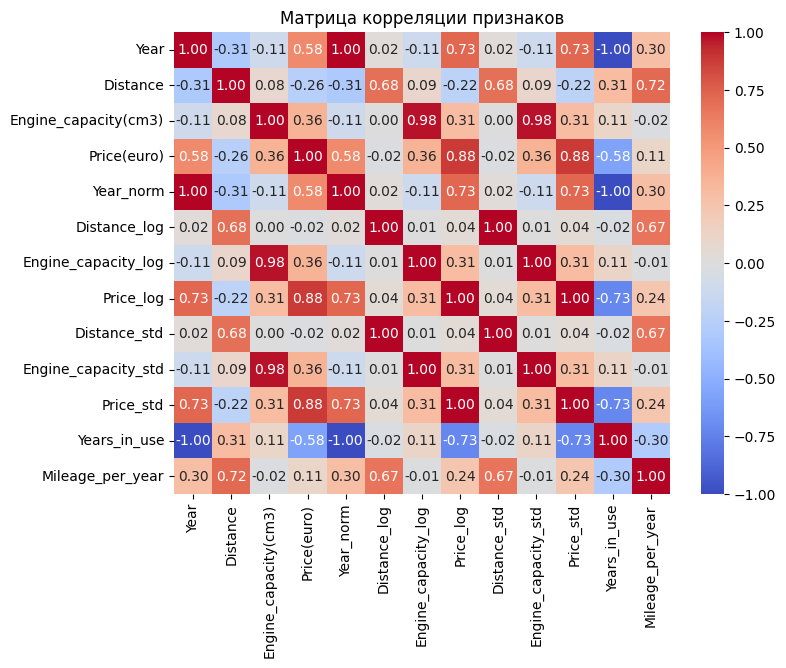

In [136]:
corr_matrix = cleandataset.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляции признаков")
plt.show()



# 8. Сохранение DataFrame в файл

Сохранить в файлы два датасета: с кодированием One-Hot и Label.  
***Подсказка:*** *Использовать метод `.to_csv(path, index) `

In [137]:
df_se.to_csv('cars_num.csv',index=False)
df_ohe.to_csv('cars_onehot.csv',index=False)